In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("../dataset/data.csv")
df.head()

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality
0,21.0,Female,1,5.89208,2.144395,7.32363,5.462224,Arts,ENTP
1,24.0,Female,1,2.48366,3.206188,8.06876,3.765012,Unknown,INTP
2,26.0,Female,1,7.02910,6.469302,4.16472,5.454442,Others,ESFP
3,30.0,Male,0,5.46525,4.179244,2.82487,5.080477,Sports,ENFJ
4,31.0,Female,0,3.59804,6.189259,5.31347,3.677984,Others,ISFP


In [8]:
df.isnull().sum()


Age                   0
Gender                0
Education             0
Introversion Score    0
Sensing Score         0
Thinking Score        0
Judging Score         0
Interest              0
Personality           0
dtype: int64

Label Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
columns=df[["Gender","Interest","Personality"]]
for col in columns:
    df[col]=le.fit_transform(df[col])

In [11]:
print(df.head())

    Age  Gender  Education  Introversion Score  Sensing Score  Thinking Score  \
0  21.0       0          1             5.89208       2.144395         7.32363   
1  24.0       0          1             2.48366       3.206188         8.06876   
2  26.0       0          1             7.02910       6.469302         4.16472   
3  30.0       1          0             5.46525       4.179244         2.82487   
4  31.0       0          0             3.59804       6.189259         5.31347   

   Judging Score  Interest  Personality  
0       5.462224         0            3  
1       3.765012         4           11  
2       5.454442         1            5  
3       5.080477         2            0  
4       3.677984         1           13  


EDA

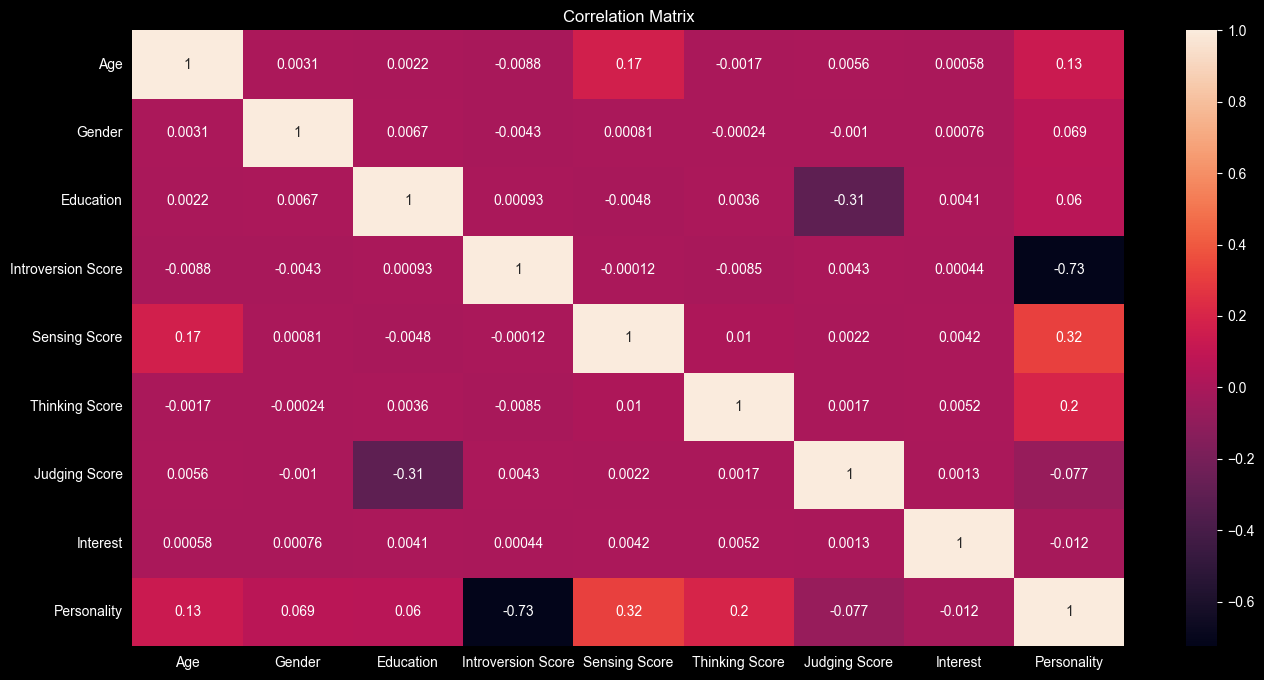

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
plt.title("Correlation Matrix")
sns.heatmap(df.corr(),annot=True)
plt.show()

Feature engineering

In [38]:
df["Intellectual_Alignment"]=df["Interest"]*df["Education"]
df["Thinking_power"]=df["Sensing Score"]*df["Thinking Score"]
df["Gender thinking"]=df["Gender"]*df["Thinking Score"]
df["Age interest"]=df["Age"]*df["Interest"]


Feature Selection

In [39]:
X=df.drop("Personality",axis=1
          )
y=df["Personality"]

Train test split

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)


Grid search CV

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Best Score: 0.9004744101906871


Model training

In [58]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100,max_depth=None,min_samples_split=10,criterion="gini", random_state=0)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

Metrices

In [60]:
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
print("Accuracy_Score:",accuracy_score(y_test,y_pred))


Accuracy_Score: 0.9028460395473769


In [61]:
print("Confusion_Matrix:",confusion_matrix(y_test,y_pred))

Confusion_Matrix: [[500   0   0   0  21   0   0   0  38   1   0   0   4   0   0   0]
 [  0 458   0   0   0  21   0   0   0  40   0   0   0   3   0   0]
 [  2   0 497   1   0   0  28   0   0   0  38   0   0   0   2   0]
 [  0   0   0 458   0   0   0  23   0   0   0  40   0   0   0   0]
 [  7   0   0   0 503   0   0   0   1   0   0   0  39   0   0   0]
 [  0   5   0   0   0 532   0   0   0   0   0   0   0  48   0   0]
 [  0   0   4   0   0   0 527   0   0   0   1   0   0   0  30   0]
 [  0   0   0   1   0   0   1 486   0   0   0   0   0   1   0  49]
 [ 37   0   0   0   1   0   0   0 492   2   0   0  17   1   0   0]
 [  0  25   0   0   0   1   0   0   0 498   0   0   0  22   0   0]
 [  0   0  42   0   0   0   2   0   1   0 467   1   1   0  23   0]
 [  0   0   0  34   0   0   0   0   0   2   0 465   0   0   1  38]
 [  0   0   0   0  37   0   0   0   5   0   0   0 489   1   1   0]
 [  0   1   0   0   1  30   0   0   0   4   0   0   0 507   0   0]
 [  0   0   0   0   0   0  27   0   0   0   

In [62]:
print("Classification_Report:",classification_report(y_test,y_pred))

Classification_Report:               precision    recall  f1-score   support

           0       0.92      0.89      0.90       564
           1       0.94      0.88      0.91       522
           2       0.92      0.88      0.89       568
           3       0.93      0.88      0.90       521
           4       0.89      0.91      0.90       550
           5       0.91      0.91      0.91       585
           6       0.90      0.94      0.92       562
           7       0.89      0.90      0.90       538
           8       0.92      0.89      0.91       550
           9       0.91      0.91      0.91       546
          10       0.92      0.87      0.89       537
          11       0.92      0.86      0.89       540
          12       0.89      0.92      0.90       533
          13       0.87      0.93      0.90       543
          14       0.90      0.94      0.92       539
          15       0.85      0.93      0.89       551

    accuracy                           0.90      8749
   

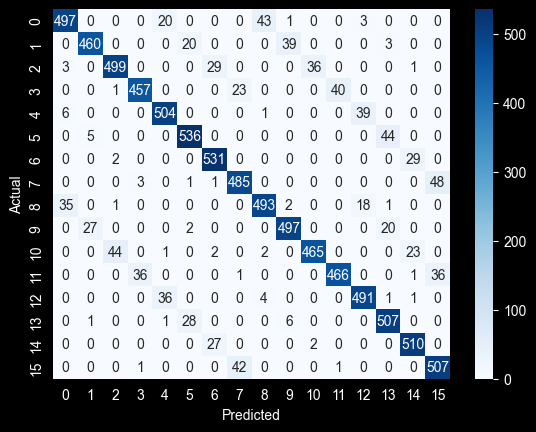

In [52]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [54]:
print("Accuracy_Score:",accuracy_score(y_test,y_pred_new))

Accuracy_Score: 0.1164704537661447
